In [8]:
import jax.numpy as jnp
import neural_tangents as nt
from neural_tangents import stax
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split

from jax.nn import one_hot
from tqdm import tqdm

from utils.classificationDataGeneration import make_multitask_regression_datasets, make_orthogonal_multitask_regression_datasets

In [9]:
def compute_infinite_ntk(kernel_fn, x_train, x_test):
    """
    Compute the empirical Neural Tangent Kernel (NTK)0 for 
    between training and test data.
    """
    
    # Compute the kernel matrices, diagonal
    ntk_train_train = kernel_fn(x_train, x_train, get='ntk')
    ntk_test_train  = kernel_fn(x_test, x_train, get='ntk')
    ntk_test_test   = kernel_fn(x_test, x_test, get='ntk')

    return {
        "train_train": ntk_train_train,
        "test_train": ntk_test_train,
        "test_test": ntk_test_test
    }

def compute_empirical_ntk(apply_fn, params, x_train, x_test):
    """
    Compute the empirical Neural Tangent Kernel (NTK)
    between training and test data.
    """
    
    # Create a function that computes the empirical NTK
    ntk_fn = nt.empirical_ntk_fn(apply_fn, trace_axes=(-1,), vmap_axes=0, implementation=nt.NtkImplementation.STRUCTURED_DERIVATIVES)
   
    # Compute the kernel matrices
    ntk_train_train = ntk_fn(x_train, x_train, params)
    ntk_test_train  = ntk_fn(x_test, x_train, params)
    ntk_test_test   = ntk_fn(x_test, x_test, params)

    return {
        "train_train": ntk_train_train,
        "test_train": ntk_test_train,
        "test_test": ntk_test_test
    }

Reproduce the results in Bietti et al. (https://arxiv.org/pdf/1905.12173), points in unit circle, nonlinear regression (sin(k theta)) and zero biases.

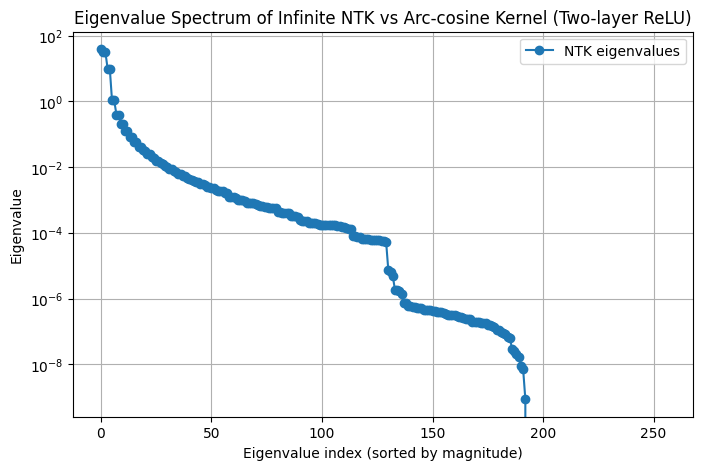

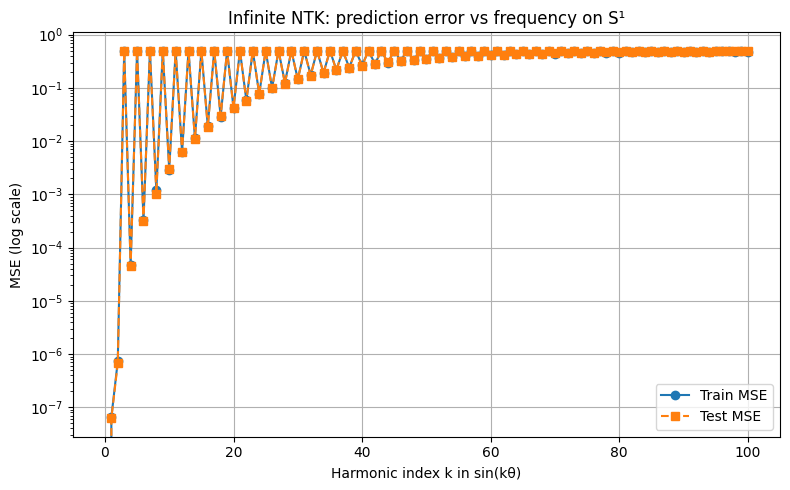

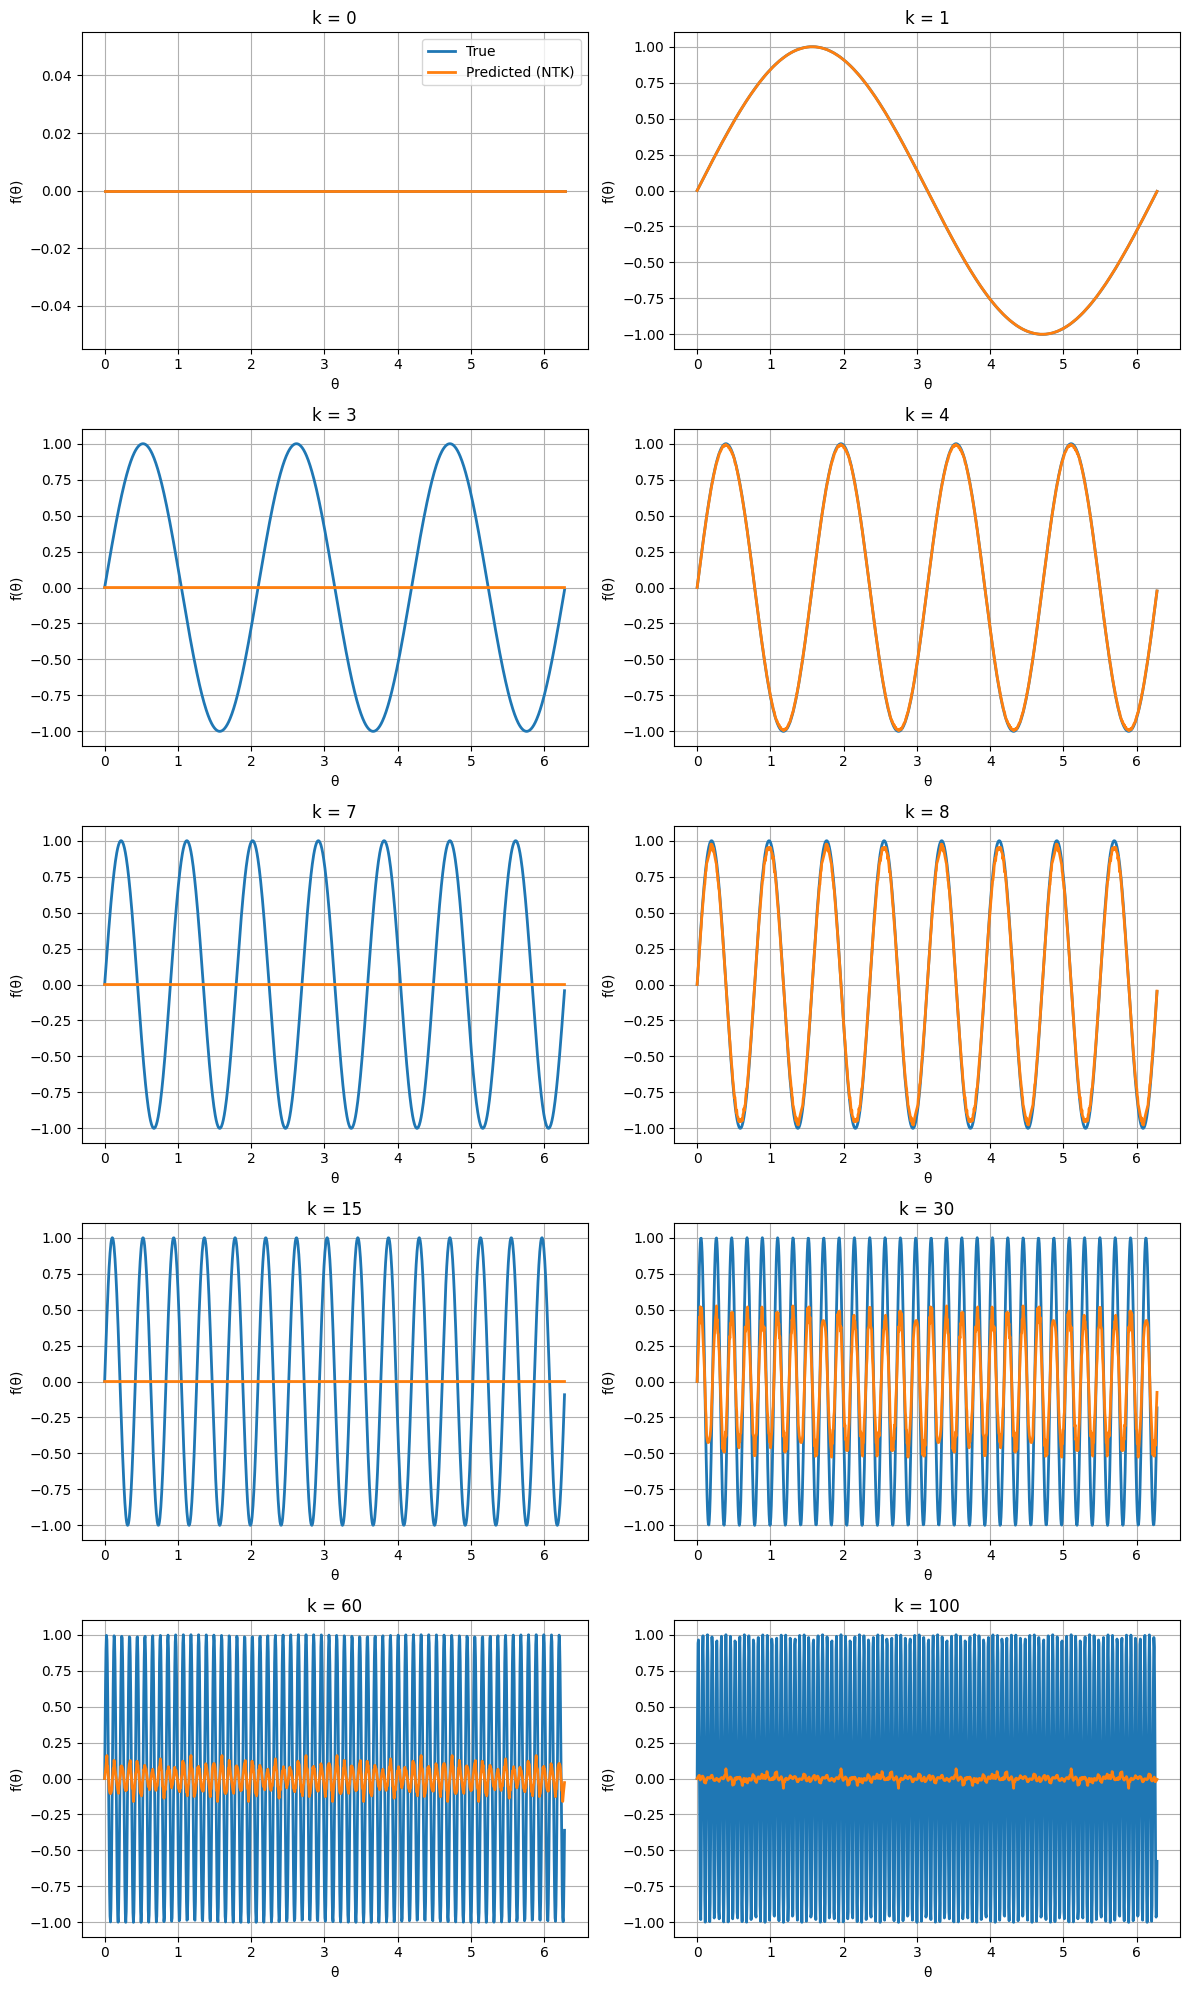

In [10]:
#Data creation
N_train = 256
N_test  = 1024

angles_train = jnp.linspace(0, 2*jnp.pi, N_train, endpoint=False)
angles_test  = jnp.linspace(0, 2*jnp.pi, N_test, endpoint=False)

X_train = jnp.column_stack([jnp.cos(angles_train), jnp.sin(angles_train)])
X_test  = jnp.column_stack([jnp.cos(angles_test),  jnp.sin(angles_test)])

X_train = jnp.array(X_train, dtype=jnp.float32)
X_test  = jnp.array(X_test,  dtype=jnp.float32)

# Define network, any width is fine since we use infinite approx
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(1, W_std=1, b_std=0, parameterization="ntk"),
    stax.Relu(),
    stax.Dense(1, W_std=1, b_std=0, parameterization="ntk")
)

kernel_fn = nt.batch(kernel_fn, device_count=-1)

# Precompute kernels
K_train = jnp.array(kernel_fn(X_train, X_train, 'ntk'))
K_test_train = jnp.array(kernel_fn(X_test, X_train, 'ntk'))

# Do eigen-decomposition of the train kernel matrix
eigvals_ntk = jnp.linalg.eigvalsh(K_train)

# Sort eigenvalues for plotting.
eigvals_ntk = jnp.sort(eigvals_ntk)[::-1]

# Plot the eigenvalue spectrum.
plt.figure(figsize=(8,5))
plt.plot(eigvals_ntk, 'o-', label='NTK eigenvalues')
plt.yscale('log')
plt.xlabel("Eigenvalue index (sorted by magnitude)")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum of Infinite NTK vs Arc-cosine Kernel (Two-layer ReLU)")
plt.legend()
plt.grid(True)
plt.show()

# Kernel ridge regression on sin(kθ)
reg = 1e-2
K_reg = K_train + reg * jnp.eye(N_train)

K_max = 100
train_mse = []
test_mse = []

# Store predictions for selected ks
selected_ks = [0, 1, 3, 4, 7, 8, 15, 30, 60, 100]
predictions = {}

for k in range(K_max + 1):

    y_train = jnp.sin(k * angles_train)
    y_test  = jnp.sin(k * angles_test)

    alpha = jnp.linalg.solve(K_reg, y_train)

    y_pred_train = K_train @ alpha
    y_pred_test  = K_test_train @ alpha

    train_err = jnp.mean((y_pred_train - y_train)**2)
    test_err  = jnp.mean((y_pred_test  - y_test)**2)

    train_mse.append(train_err)
    test_mse.append(test_err)

    # Save predictions only for selected k
    if k in selected_ks:
        predictions[k] = (y_test, y_pred_test)

# Plot train/test error vs k
ks = jnp.arange(K_max + 1)
plt.figure(figsize=(8,5))
plt.semilogy(ks, train_mse, 'o-', label='Train MSE')
plt.semilogy(ks, test_mse,  's--', label='Test MSE')
plt.xlabel("Harmonic index k in sin(kθ)")
plt.ylabel("MSE (log scale)")
plt.title("Infinite NTK: prediction error vs frequency on S¹")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot true vs predicted signals for selected ks
n_cols = 2
n_rows = int(jnp.ceil(len(selected_ks) / n_cols))
plt.figure(figsize=(12, 4 * n_rows))
for i, k in enumerate(selected_ks):
    y_true, y_pred = predictions[k]
    ax = plt.subplot(n_rows, n_cols, i+1)
    ax.plot(angles_test, y_true, label="True", lw=2)
    ax.plot(angles_test, y_pred, label="Predicted (NTK)", lw=2)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("θ")
    ax.set_ylabel("f(θ)")
    ax.grid(True)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()


Let's see what happens if the biases are not at zero.

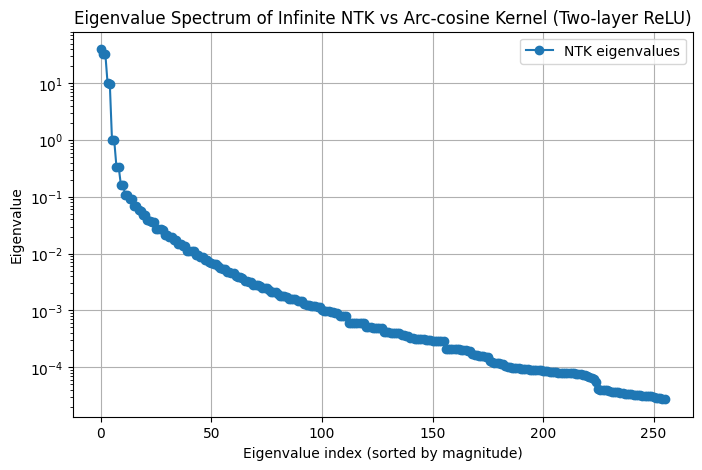

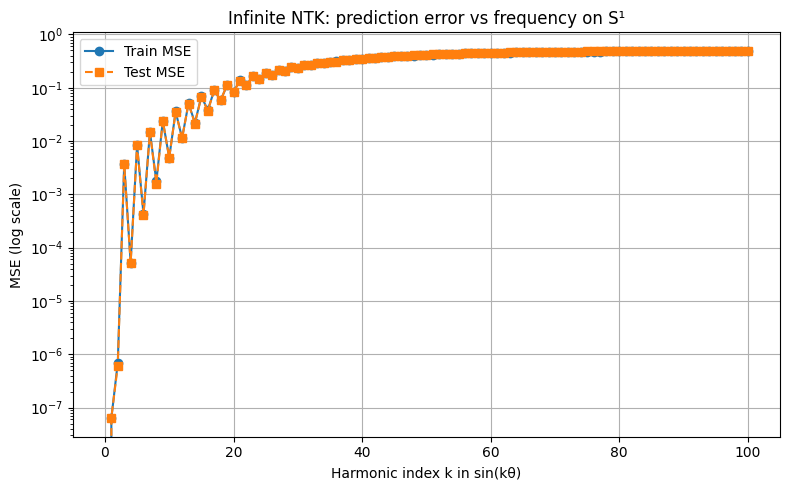

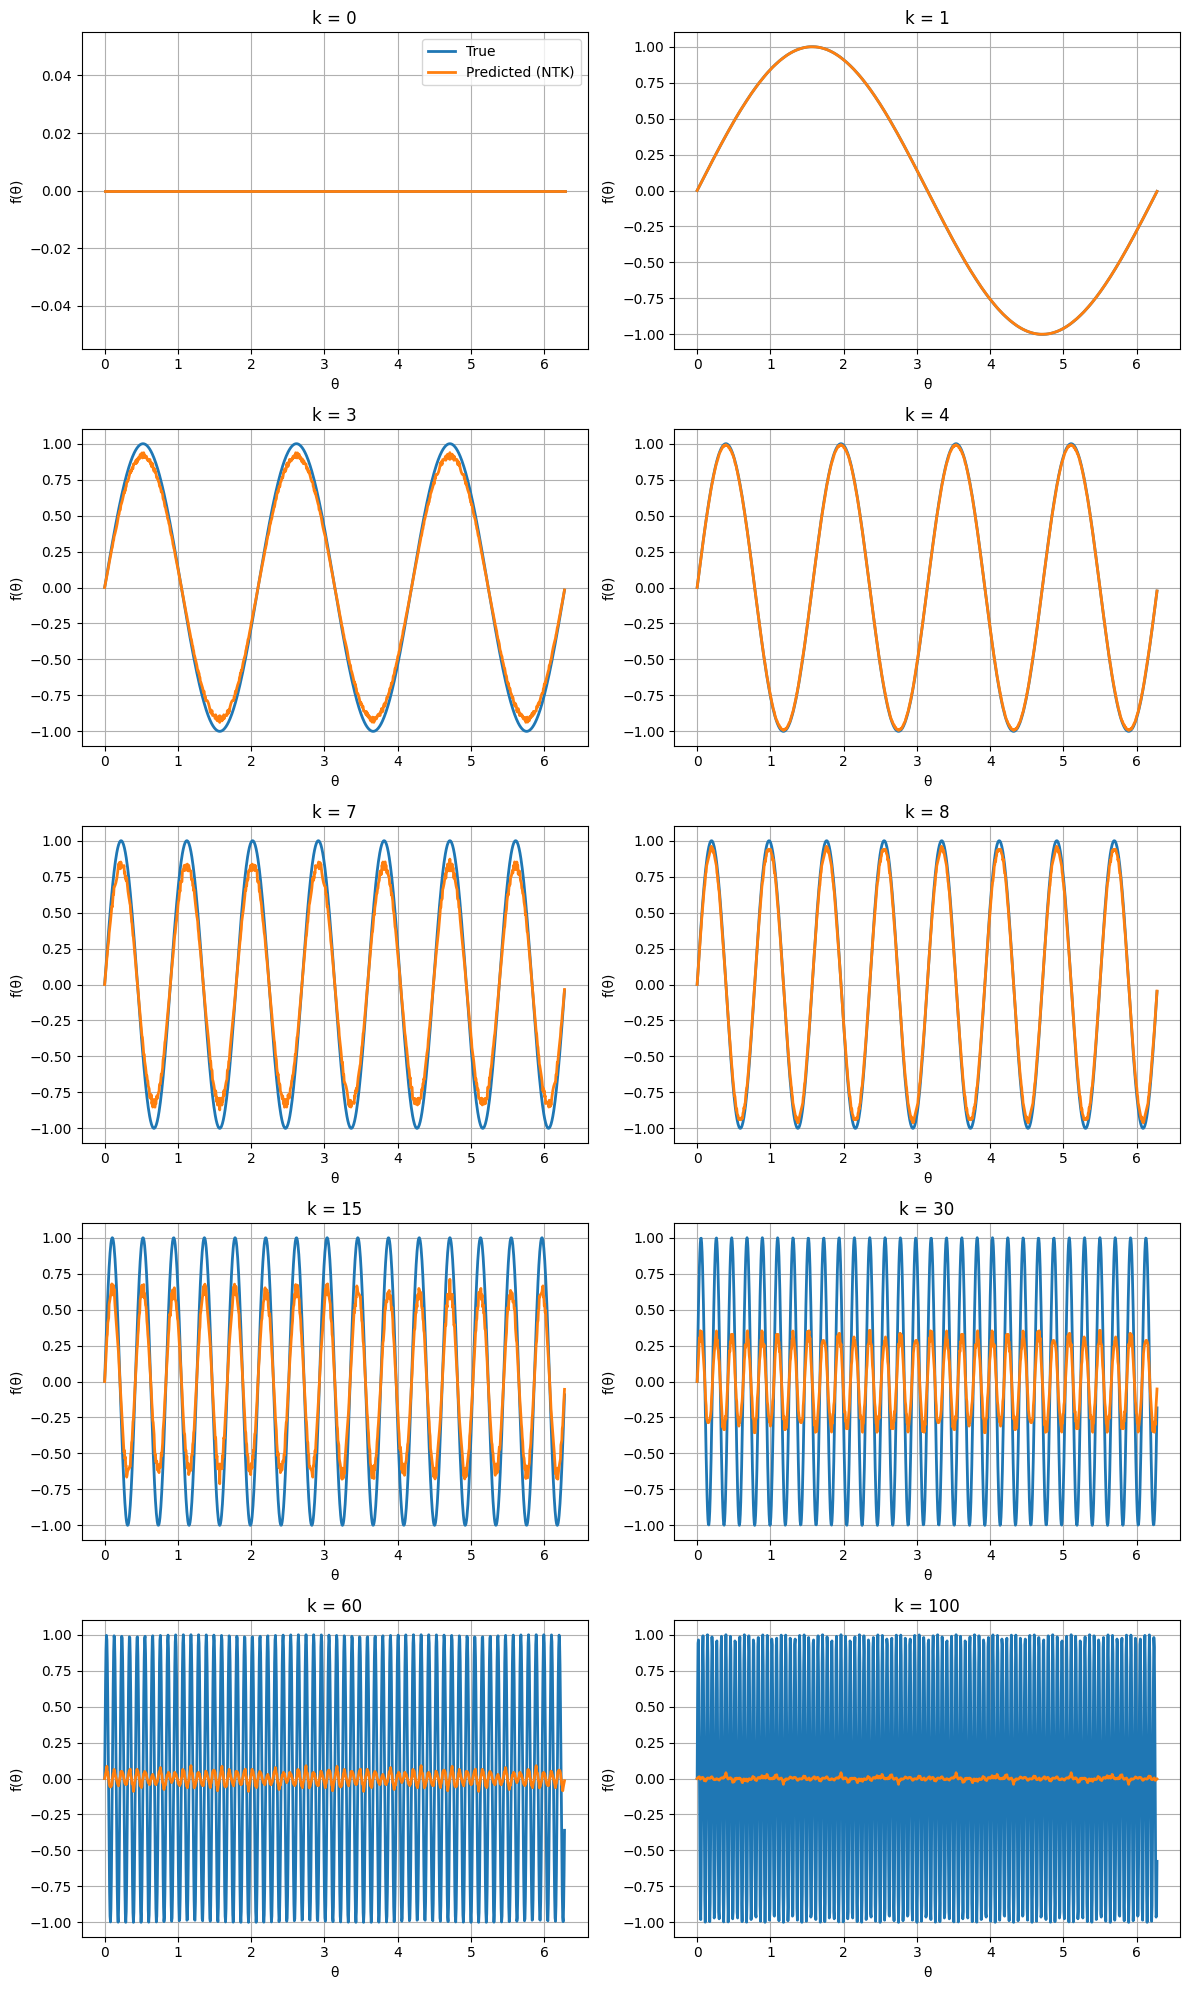

In [11]:
#Data creation
N_train = 256
N_test  = 1024

angles_train = jnp.linspace(0, 2*jnp.pi, N_train, endpoint=False)
angles_test  = jnp.linspace(0, 2*jnp.pi, N_test, endpoint=False)

X_train = jnp.column_stack([jnp.cos(angles_train), jnp.sin(angles_train)])
X_test  = jnp.column_stack([jnp.cos(angles_test),  jnp.sin(angles_test)])

X_train = jnp.array(X_train, dtype=jnp.float32)
X_test  = jnp.array(X_test,  dtype=jnp.float32)

# Define network, any width is fine since we use infinite approx
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(1, W_std=1, b_std=0.05, parameterization="ntk"),
    stax.Relu(),
    stax.Dense(1, W_std=1, b_std=0.05, parameterization="ntk")
)

kernel_fn = nt.batch(kernel_fn, device_count=-1)

# Precompute kernels
K_train = jnp.array(kernel_fn(X_train, X_train, 'ntk'))
K_test_train = jnp.array(kernel_fn(X_test, X_train, 'ntk'))

# Do eigen-decomposition of the train kernel matrix
eigvals_ntk = jnp.linalg.eigvalsh(K_train)

# Sort eigenvalues for plotting.
eigvals_ntk = jnp.sort(eigvals_ntk)[::-1]

# Plot the eigenvalue spectrum.
plt.figure(figsize=(8,5))
plt.plot(eigvals_ntk, 'o-', label='NTK eigenvalues')
plt.yscale('log')
plt.xlabel("Eigenvalue index (sorted by magnitude)")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum of Infinite NTK vs Arc-cosine Kernel (Two-layer ReLU)")
plt.legend()
plt.grid(True)
plt.show()

# Kernel ridge regression on sin(kθ)
reg = 1e-2
K_reg = K_train + reg * jnp.eye(N_train)

K_max = 100
train_mse = []
test_mse = []

# Store predictions for selected ks
selected_ks = [0, 1, 3, 4, 7, 8, 15, 30, 60, 100]
predictions = {}

for k in range(K_max + 1):

    y_train = jnp.sin(k * angles_train)
    y_test  = jnp.sin(k * angles_test)

    alpha = jnp.linalg.solve(K_reg, y_train)

    y_pred_train = K_train @ alpha
    y_pred_test  = K_test_train @ alpha

    train_err = jnp.mean((y_pred_train - y_train)**2)
    test_err  = jnp.mean((y_pred_test  - y_test)**2)

    train_mse.append(train_err)
    test_mse.append(test_err)

    # Save predictions only for selected k
    if k in selected_ks:
        predictions[k] = (y_test, y_pred_test)

# Plot train/test error vs k
ks = jnp.arange(K_max + 1)
plt.figure(figsize=(8,5))
plt.semilogy(ks, train_mse, 'o-', label='Train MSE')
plt.semilogy(ks, test_mse,  's--', label='Test MSE')
plt.xlabel("Harmonic index k in sin(kθ)")
plt.ylabel("MSE (log scale)")
plt.title("Infinite NTK: prediction error vs frequency on S¹")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot true vs predicted signals for selected ks
n_cols = 2
n_rows = int(jnp.ceil(len(selected_ks) / n_cols))
plt.figure(figsize=(12, 4 * n_rows))
for i, k in enumerate(selected_ks):
    y_true, y_pred = predictions[k]
    ax = plt.subplot(n_rows, n_cols, i+1)
    ax.plot(angles_test, y_true, label="True", lw=2)
    ax.plot(angles_test, y_pred, label="Predicted (NTK)", lw=2)
    ax.set_title(f"k = {k}")
    ax.set_xlabel("θ")
    ax.set_ylabel("f(θ)")
    ax.grid(True)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()


It appears that the introduction of biases (increasing the std from 0 to 0.05) has increased the space of representable functions to the odd harmonics too. Let's see how variations in W_std and b_std modify the results.

In [13]:
# Helper functions

# Run since ntk setup
def run_ntk_single(
    W_std=1.0,
    b_std=1.0,
    N_train=256,
    N_test=1024,
    K_max=100,
    reg=1e-2,
    selected_ks=[0,1,3,4,7,8,15,30,60,100],
    trainable=("W","b")
):
    """Run NTK spectral + prediction experiment for one configuration."""

    # Data on S1
    angles_train = jnp.linspace(0, 2*jnp.pi, N_train, endpoint=False)
    angles_test  = jnp.linspace(0, 2*jnp.pi, N_test, endpoint=False)

    X_train = jnp.column_stack([jnp.cos(angles_train), jnp.sin(angles_train)])
    X_test  = jnp.column_stack([jnp.cos(angles_test),  jnp.sin(angles_test)])

    X_train = jnp.array(X_train, dtype=jnp.float32)
    X_test  = jnp.array(X_test,  dtype=jnp.float32)

    # Build NTK network
    init_fn, apply_fn, kernel_fn = stax.serial(
        stax.Dense(1, W_std=W_std, b_std=b_std,
                   parameterization="ntk", trainable=trainable),
        stax.Relu(),
        stax.Dense(1, W_std=W_std, b_std=b_std,
                   parameterization="ntk", trainable=trainable)
    )
    kernel_fn = nt.batch(kernel_fn, device_count=-1)

    # Compute eigenvalues
    X_full = jnp.array(jnp.column_stack([
        jnp.cos(jnp.linspace(0,2*jnp.pi,N_train)),
        jnp.sin(jnp.linspace(0,2*jnp.pi,N_train))
    ]), dtype=jnp.float32)

    K_ntk_full = jnp.array(kernel_fn(X_full, X_full, 'ntk'))
    eigvals = jnp.sort(jnp.linalg.eigvalsh(K_ntk_full))[::-1]

    # Kernel ridge regression for sin(kθ)
    K_train = jnp.array(kernel_fn(X_train, X_train, 'ntk'))
    K_test_train = jnp.array(kernel_fn(X_test, X_train, 'ntk'))
    K_reg = K_train + reg * jnp.eye(N_train)

    train_mse = []
    test_mse = []
    predictions = {}

    for k in range(K_max+1):
        y_train = jnp.sin(k * angles_train)
        y_test  = jnp.sin(k * angles_test)

        alpha = jnp.linalg.solve(K_reg, y_train)
        y_pred_train = K_train @ alpha
        y_pred_test  = K_test_train @ alpha

        train_mse.append(jnp.mean((y_pred_train - y_train)**2))
        test_mse.append(jnp.mean((y_pred_test - y_test)**2))

        if k in selected_ks:
            predictions[k] = dict(true=y_test, pred=y_pred_test)

    # Return full result object
    return dict(
        W_std=W_std,
        b_std=b_std,
        eigvals=jnp.array(eigvals),
        train_mse=jnp.array(train_mse),
        test_mse=jnp.array(test_mse),
        predictions=predictions,
        selected_ks=selected_ks,
        trainable=trainable
    )

# Run multiple configs
def run_ntk_multiple(config_list):
    results = []
    for cfg in tqdm(config_list):
        res = run_ntk_single(**cfg)
        results.append(res)
    return results

# Plot eigenvalues
def plot_all_eigenspectra(all_results):
    plt.figure(figsize=(8,5))

    for res in all_results:
        trainable="both" if res['trainable']==("W","b") else "W" if res['trainable']==("W") else "b"
        label = f"W={res['W_std']}, b={res['b_std']}, train={trainable}"
        plt.plot(res['eigvals'], label=label)

    plt.yscale("log")
    plt.xlabel("Eigenvalue index")
    plt.ylabel("Eigenvalue")
    plt.title("NTK Eigenvalue Spectra (multiple configs)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot MSE curves
def plot_all_mse_curves(all_results):
    plt.figure(figsize=(8,5))

    for res in all_results:
        trainable="both" if res['trainable']==("W","b") else "W" if res['trainable']==("W") else "b"
        label = f"W={res['W_std']}, b={res['b_std']}, train={trainable}"
        #plt.semilogy(res['train_mse'], label=f"Train {label}")
        plt.semilogy(res['test_mse'], label=f"Test {label}")

    plt.xlabel("Harmonic index k")
    plt.ylabel("MSE (log scale)")
    plt.title("Prediction Error vs Frequency (multiple configs)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def compute_mode_capacity(res, thresholds):
    """
    Return an array where entry i is the number of Fourier modes
    with test MSE < thresholds[i].
    """
    test_mse = res['test_mse']
    return jnp.array([jnp.sum(test_mse < t) for t in thresholds])


def compute_cutoff_frequency(res, threshold):
    """
    Return the maximum harmonic k such that test_mse[k] < threshold.
    Returns -1 if none are learnable.
    """
    test_mse = res['test_mse']
    below = jnp.where(test_mse < threshold)[0]
    return int(below.max()) if len(below) > 0 else -1

# Plot mode capacity
def plot_mode_capacity_multiple(all_results, 
                                thresholds=jnp.logspace(-6, 0, 50)):
    """
    Plot mode-learning capacity vs MSE threshold for multiple configs.
    
    Each curve = one NTK configuration.
    """

    plt.figure(figsize=(8,6))

    for res in all_results:

        trainable = ("both" if res['trainable']==("W","b") else
                     "W" if res['trainable']==("W") else
                     "b")

        label = f"W={res['W_std']}, b={res['b_std']}, train={trainable}"

        capacities = compute_mode_capacity(res, thresholds)
        plt.plot(thresholds, capacities, label=label)

    plt.xscale("log")
    plt.xlabel("MSE threshold")
    plt.ylabel("# of learnable Fourier modes")
    plt.title("Learnable Bandwidth vs MSE Threshold")
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

First, set biases to 0 and change std of weights

100%|██████████| 7/7 [00:01<00:00,  3.90it/s]


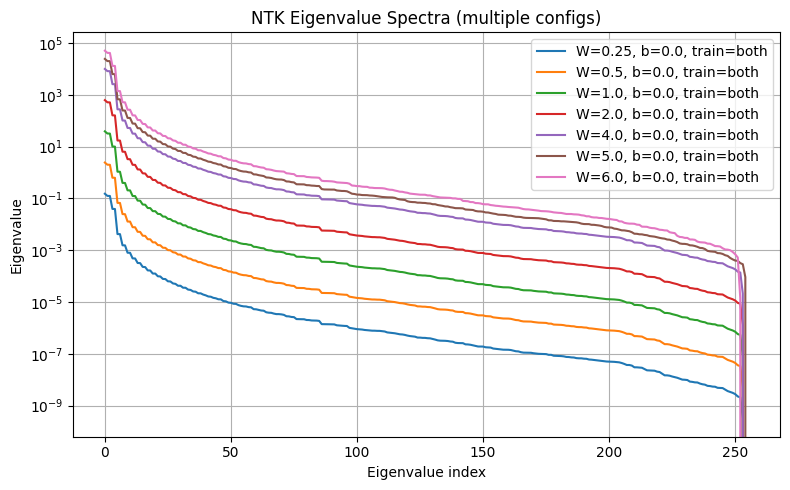

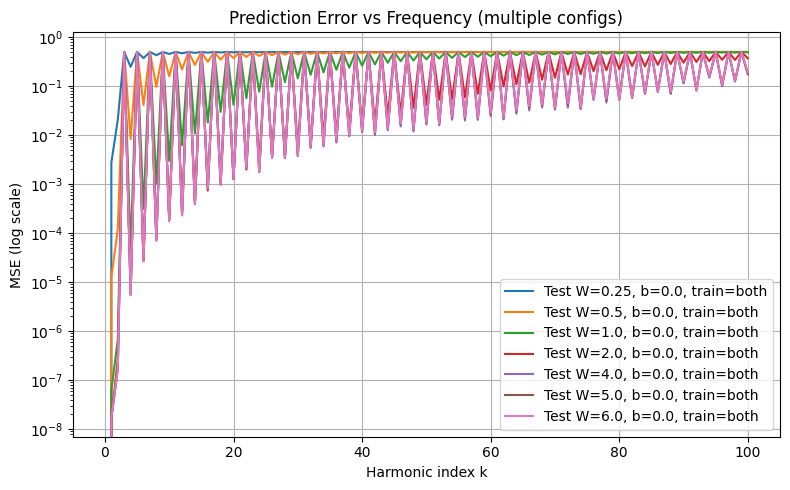

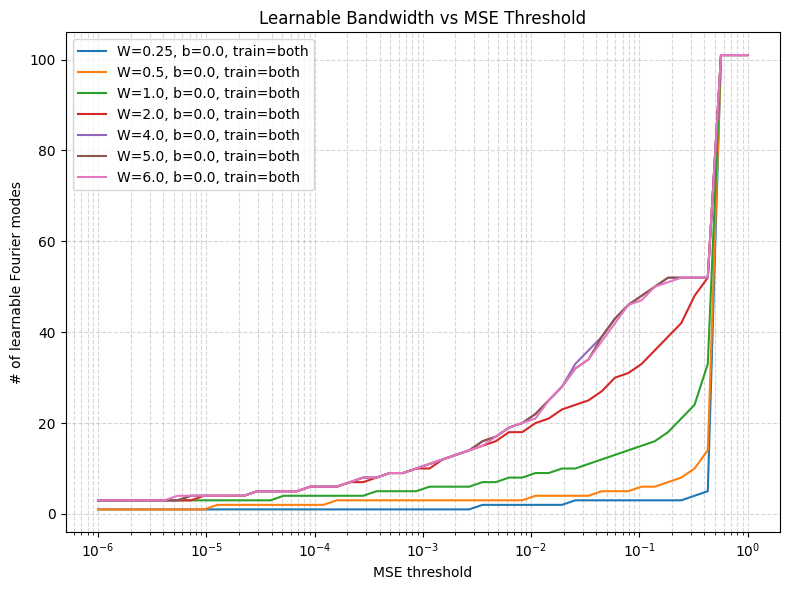

In [16]:
configs_W = [
    dict(W_std=0.25, b_std=0.0),
    dict(W_std=0.5,  b_std=0.0),
    dict(W_std=1.0,  b_std=0.0),
    dict(W_std=2.0,  b_std=0.0),
    dict(W_std=4.0,  b_std=0.0),
    dict(W_std=5.0,  b_std=0.0),
    dict(W_std=6.0,  b_std=0.0),
]

all_results = run_ntk_multiple(configs_W)

plot_all_eigenspectra(all_results)
plot_all_mse_curves(all_results)
plot_mode_capacity_multiple(all_results)

Then choose W_std=4.0 since it's the best we found and change b_std

100%|██████████| 6/6 [00:01<00:00,  3.38it/s]


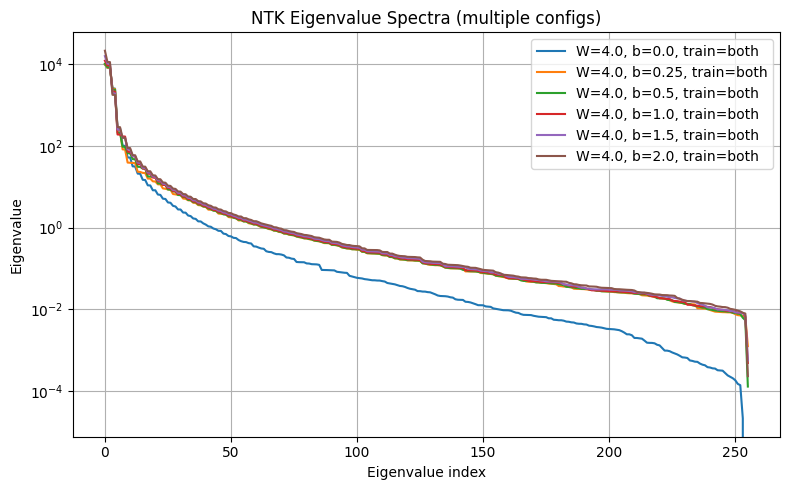

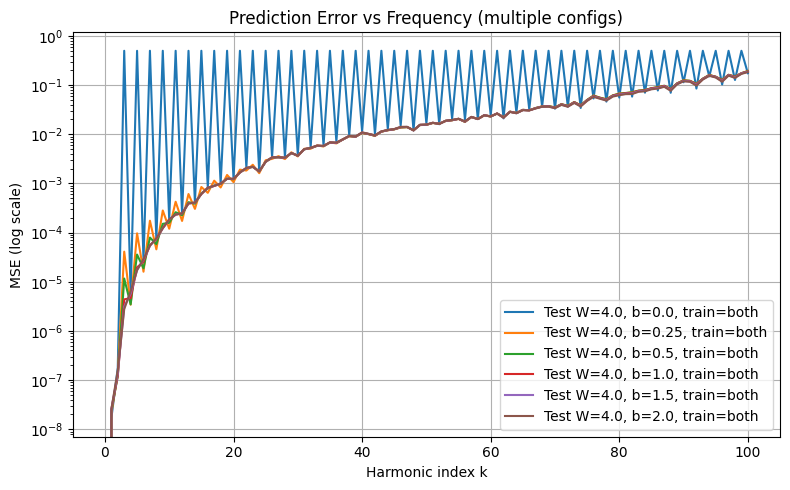

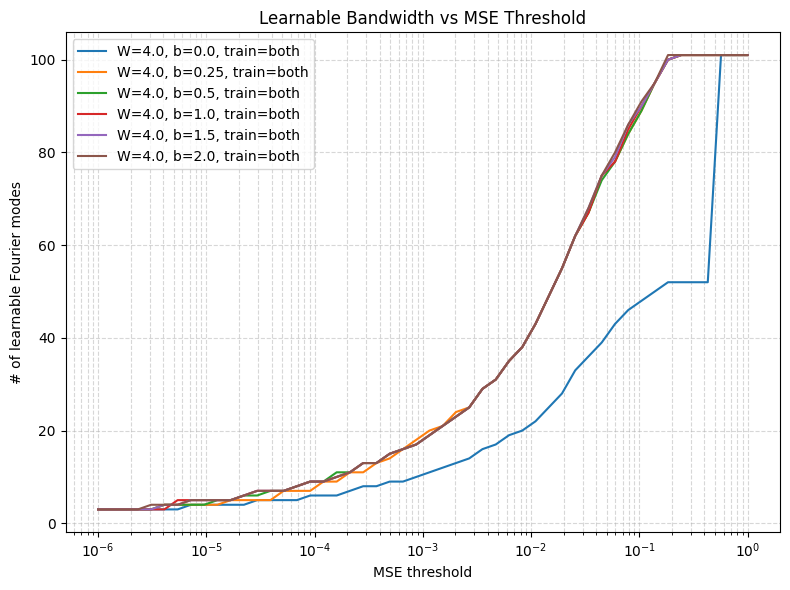

In [ ]:
configs_b = [
    dict(W_std=4.0, b_std=0.0),
    dict(W_std=4.0, b_std=0.25),
    dict(W_std=4.0, b_std=0.5),
    dict(W_std=4.0, b_std=1.0),
    dict(W_std=4.0, b_std=1.5),
    dict(W_std=4.0, b_std=2.0),
]

all_results = run_ntk_multiple(configs_b)

plot_all_eigenspectra(all_results)
plot_all_mse_curves(all_results)
plot_mode_capacity_multiple(all_results)

Finally, let's see what difference it makes using bias only NTK instead of normal NTK

100%|██████████| 2/2 [00:00<00:00,  2.93it/s]


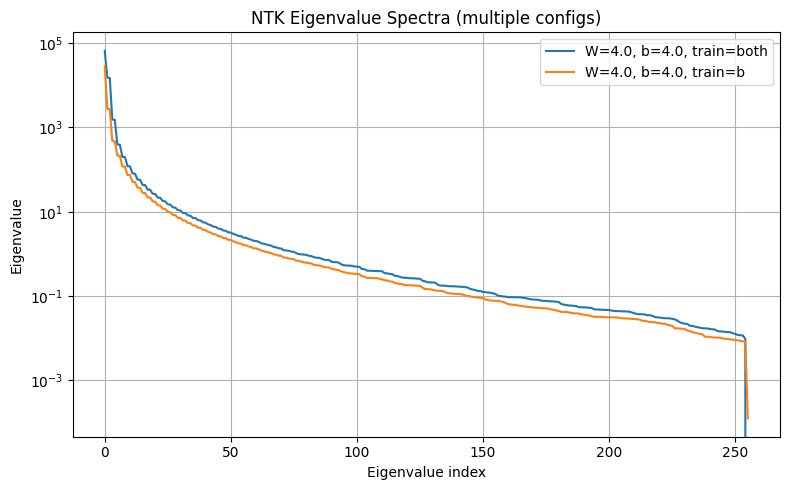

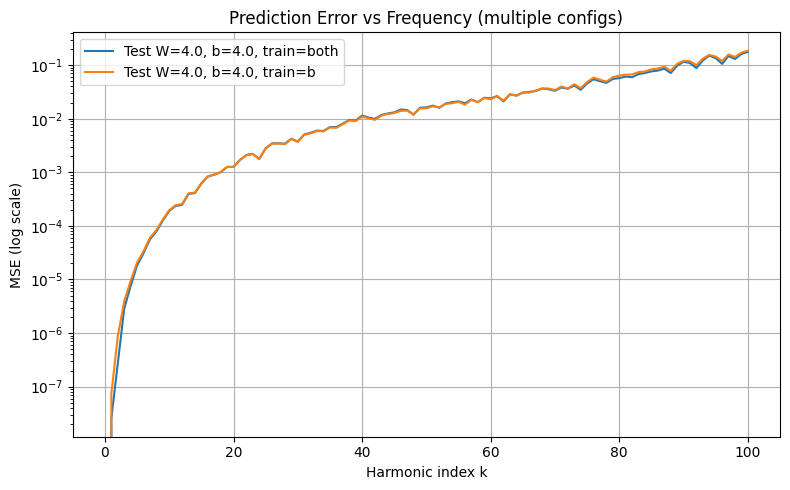

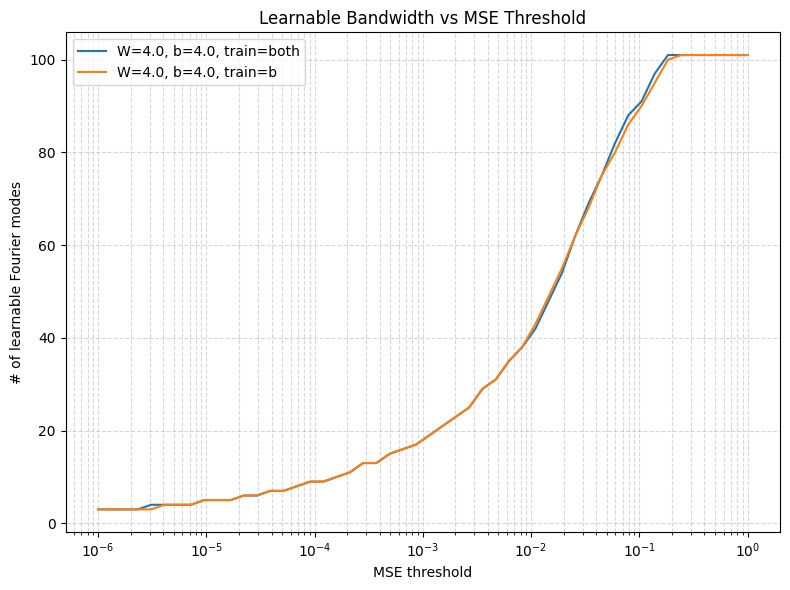

In [20]:
configs = [
    dict(W_std=4.0, b_std=4.0),
    dict(W_std=4.0, b_std=4.0, trainable=("b")),
]

all_results = run_ntk_multiple(configs)

plot_all_eigenspectra(all_results)
plot_all_mse_curves(all_results)
plot_mode_capacity_multiple(all_results)

Although before it didn't seem that b_std made much difference as long as it was higher than 0, for the bias only ntk to perform like the full ntk it makes a difference, W_std and b_std need to be equal.